In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [46]:
s7055_norm = np.loadtxt('s7055.dat')
skin_thickness = 5e-4
chord = 0.265
s7055 = np.loadtxt('s7055.dat')*chord
s7055_dl = np.linalg.norm(s7055[:-1, :] - s7055[1:, :], axis=1)
s7055_midpt = (s7055[:-1, :] + s7055[1:, :])/2
# Wing Parameters
b = 2
S = 0.53
W = 6.9*9.81



In [47]:

chord_fuselage = 800e-3
chord_ht = 0.172
chord_vt = 0.178

span_vt = 0.77
span_ht = 0.26

naca0012 = np.loadtxt('naca0012.dat')
naca0012_ht = naca0012*chord_ht
naca0012_vt = naca0012*chord_vt

naca0012_ht_dl = np.linalg.norm(naca0012_ht[:-1, :] - naca0012_ht[1:, :], axis=1)
naca0012_vt_dl = np.linalg.norm(naca0012_vt[:-1, :] - naca0012_vt[1:, :], axis=1)

g = 9.81
rho_Al1100 = 2700
rho_Al6061 = 2700
sp_length = 1.1
wing_length = 1.8
airfoil_curved_length = np.sum(s7055_dl)
n_ribs = 5
n_bk = 4

# Assumption: Quater Chord is the Aerodynamic Center of the Wing
# Coordinates along X Axis from Nose
ACw = 200e-3
NP = 300e-3
CG = 260e-3
nose_lg = 55e-3
main_lg = 370e-3

idx_TE = 0
idx_LE = 42
n_airfoil_pts = s7055.shape[0] - 1

s7055_u = s7055[:idx_LE + 1, :]
s7055_u = np.flip(s7055_u, axis=0)  # From LE to TE
s7055_l = s7055[idx_LE:, :]   
tD = skin_thickness 

naca0025 = np.loadtxt('naca0025.dat')
naca0025 *= chord_fuselage


In [48]:
W_battery = 1.276
x_battery = 140
len_tailboom = 488e-3
x_spar = ACw + (0.3174 - 0.25)*chord
x_cg_fg_tb = 39e-3
W_fg_tb = 870e-3        # Weight of the Fuselage Skin and the Tail Boom
W_payload = 1.2    

In [49]:
sp_flange_length = 20e-3
sp_web_height = 28e-3
sp_thickness = 1e-3
sp_length = 1100e-3
rho_Al6061 = 2700

In [50]:
A_airfoil_u = np.trapz(s7055_u[:, 1], s7055_u[:, 0])
A_airfoil_l = np.trapz(s7055_l[:, 1], s7055_l[:, 0])
A_airfoil = A_airfoil_u - A_airfoil_l

In [51]:
W_servo = 55e-3
W_esc = 60e-3
W_spar = (2*sp_flange_length + sp_web_height) * sp_thickness * sp_length * rho_Al6061
W_rib = A_airfoil * tD * rho_Al1100
W_motor_prop = (145 + 30)*1e-3
W_airfoil_skin = wing_length * tD * airfoil_curved_length * rho_Al1100
W_spar_total = 2*n_ribs*W_rib + W_spar + 2*W_motor_prop + 2*(W_esc + W_servo) + W_airfoil_skin

In [52]:
W_pixhawk_FC = 40e-3
W_voltage_regulator = 12e-3
W_power_distribution = 16e-3
W_controller_avionics = W_pixhawk_FC + W_voltage_regulator + W_power_distribution

In [53]:
W_reciever = 16e-3
W_FPV_videocam = 16e-3
W_video_transmitter = 36e-3
W_transmission_avionics = W_reciever + W_FPV_videocam + W_video_transmitter

In [54]:
W_skin_ht = rho_Al1100 * tD * span_ht * np.sum(naca0012_ht_dl)
W_skin_vt = rho_Al1100 * tD * span_ht * np.sum(naca0012_ht_dl)
W_servo = 55e-3
W_tail_total = W_skin_ht + W_skin_vt + 3*W_servo

In [55]:
x_VT_LE = 910e-3

In [56]:
def sfd_bmd_fuse(L, p_pos, p_mag, m_pos=None, m_mag=None, npts=5000):

    # Convert point-force inputs to 1D NumPy arrays
    p_pos = np.asarray(p_pos, dtype=float).flatten()
    p_mag = np.asarray(p_mag, dtype=float).flatten()

    # Handle point moments
    if m_pos is None:
        m_pos = np.array([])
        m_mag = np.array([])
    else:
        m_pos = np.asarray(m_pos, dtype=float).flatten()
        m_mag = np.asarray(m_mag, dtype=float).flatten()

    # Discretized x-coordinate
    x_grid = np.linspace(0, L, npts)
    # SHEAR FORCE DIAGRAM

    # True wherever point load position <= x
    ind = p_pos[:, np.newaxis] <= x_grid[np.newaxis, :]

    # Sum all point loads encountered
    V = -np.sum(
        p_mag[:, np.newaxis] * ind,
        axis=0
    )

    # BENDING MOMENT FROM POINT FORCES

    dx = x_grid[np.newaxis, :] - p_pos[:, np.newaxis]

    # Only loads to the left of x contribute
    dx[dx < 0] = 0

    M = np.sum(
        p_mag[:, np.newaxis] * dx,
        axis=0
    )

    # BENDING MOMENT FROM POINT MOMENTS

    if len(m_pos) > 0:

        # A point moment causes a step/jump in the BMD
        moment_ind = m_pos[:, np.newaxis] <= x_grid[np.newaxis, :]

        M += np.sum(
            m_mag[:, np.newaxis] * moment_ind,
            axis=0
        )


    # PLOT SFD AND BMD
    #plt.rcParams.update({'font.size': 20})

    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    font_size = 20
    # -------------------------
    # Shear Force Diagram
    # -------------------------

    axes[0].plot(x_grid, V, linewidth=1.8)

    axes[0].set_xlabel("x (m)", fontsize=font_size)
    axes[0].set_ylabel("Shear V(x) (N)",fontsize=font_size+2)
    axes[0].set_title("Shear Force Diagram", fontsize=font_size+4)
    axes[0].tick_params(axis='both', which='major', labelsize=font_size)
    axes[0].grid(True)

    # -------------------------
    # Bending Moment Diagram
    # -------------------------

    axes[1].plot(x_grid, M, linewidth=1.8)

    axes[1].set_xlabel("x (m)", fontsize=font_size)
    axes[1].set_ylabel("Moment M(x) (N·m)", fontsize=font_size+2)
    axes[1].set_title("Bending Moment Diagram", fontsize=font_size+4)
    axes[1].tick_params(axis='both', which='major', labelsize=font_size)
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('sfd_bmd_fuse.png', dpi=300)
    plt.show()

    return x_grid, V, M

In [57]:
tail_arm_tailboom_bulkhead = len_tailboom - 50e-3 - 0.75 * (chord_ht + chord_vt)/2
x_tail = 650e-3 + len_tailboom

L = x_tail + 0.75 * (chord_ht + chord_vt)/2

Weight = (W_transmission_avionics + W_battery + W_spar_total + W_payload + W_controller_avionics + W_fg_tb + W_tail_total)*g
Lw = Weight


print(x_tail)

p_pos = [35e-3, 140e-3, ACw + (0.3174 - 0.25)*chord, 270e-3, 310e-3, 390e-3, x_tail]
p_mag = [-W_transmission_avionics*g, -W_battery*g, Lw - W_spar_total*g, -W_payload*g, -W_controller_avionics*g, -W_fg_tb*g, - W_tail_total*g]    # Note that Tail's Lift is Negative


1.138


In [58]:
bulkhead_xloc = np.array([nose_lg, ACw + (0.3174 - 0.25)*chord, main_lg, 650e-3])

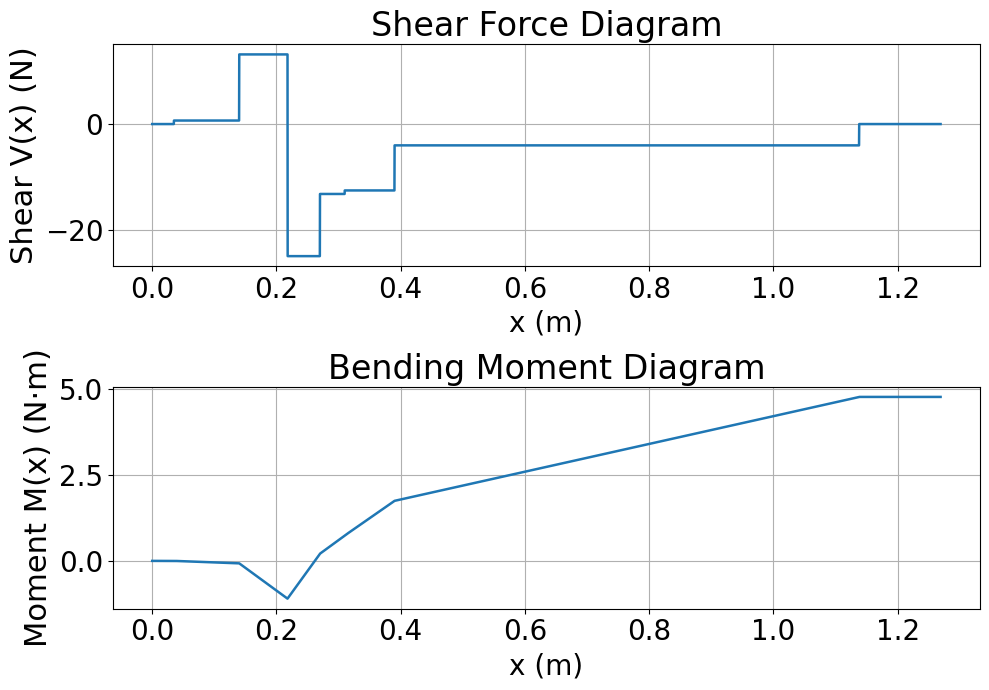

[0.055    0.217861 0.37     0.65    ]


NameError: name 'n_fos' is not defined

In [59]:

x, V, M = sfd_bmd_fuse(
    L,
    p_pos,
    p_mag
)


V_max = np.max(np.abs(V))       # N
M_max = np.max(np.abs(M))       # N.m

# Calculating the Length of the Panels

naca0025_dl = np.linalg.norm(naca0025[:-1, :] - naca0025[1:, :], axis=1)


print(bulkhead_xloc)
idx_bk_u = np.zeros(n_bk, dtype=int)
fuselage_bk_panel = np.zeros(n_bk - 1)

for i in range(n_bk):
  idx_bk_u[i] = np.argmin(np.abs(naca0025[:, 0] - bulkhead_xloc[i]))
  # plt.scatter(naca0025[idx_bk_u[i], 0], naca0025[idx_bk_u[i], 1])

for i in range(len(fuselage_bk_panel)):
  fuselage_bk_panel[i] = np.sum(naca0025_dl[idx_bk_u[i+1]:idx_bk_u[i]])

# plt.axis('equal')
# plt.show()



h_f = 0.25*chord_fuselage # maximum height
b_f = 200e-3 # maximum width
t = 0.0005 # thickness of the plate

A = 20*t # longerons only at corners

I_skin = (1/12)*(b_f * h_f**3 - (b_f - t) * (h_f - 2*t)**3) #(h_f**4 / 12) - ((h_f - t)**4 / 12)
I_boom = 4 * A * (h_f/2)**2
# I_boom = 0

sig_yield = 95e6
FOS = n_fos * n_vn * n_fatigue * k_stress_conc_factor

sig_all = sig_yield / FOS

I_req = M_max * h_f / (2 * sig_all)

if I_req > I_skin + I_boom:
    print("Longeron is not enough to withstand bending moment of fuselage")
else:
    print("Longeron is enough to withstand bending moment")

# Shear Flow & F_cr Calculation of Fuselage

I_xx = I_skin + I_boom
# Maximum shear flow
q_max = ((2 * b_f / h_f) + 1)*(V_max * t * h_f**2) / (8 * I_xx) # at the midpoint of the side webs

# Maximum shear stress
tau_max = q_max / t # Pa

# 4 Bulkhead Sections

a = fuselage_bk_panel[2] # m, Test for all the Panels
print(a)
b = 0.2 # m, Maximum value for fuselage height or width is 200mm

E = 69e9
nu = 0.33

Ra = 1 # fixed support


Kss = 5.34 + 4 * (b / a)**2

F_cr = (
    Kss * np.pi**2 * E
    / (12 * (1 - nu**2))
) * (t / b)**2 * Ra # Pa

F_cr = F_cr / FOS

# Buckling Check
print(f"F_cr    = {F_cr:.6e} Pa")
print(f"tau_max = {tau_max:.6e} Pa")

if tau_max > F_cr:
    print("Buckled")
else:
    print("Not Bukled")

print("\n------ Results ------")
print(f"V_max   = {V_max:.4f} N")
print(f"M_max   = {M_max:.4f} N.m")
print(f"I_skin  = {I_skin:.6e} m^4")
print(f"I_boom  = {I_boom:.6e} m^4")
print(f"I_req   = {I_req:.6e} m^4")
print(f"I_xx    = {I_xx:.6e} m^4")
print(f"q_max   = {q_max:.6f} N/m")
print(f"tau_max = {tau_max:.6e} Pa")
print(f"Kss     = {Kss:.6f}")
print(f"F_cr    = {F_cr:.6e} Pa")